# A core–periphery benchmark network

A synthetic network with a known community structure, used as ground truth for
the resolution sweep in
[`resolution_sweep_sbm.ipynb`](resolution_sweep_sbm.ipynb).

Specification:

* **Core**: two communities, **400** and **200** nodes, with internal edge
  probability **0.7** and **0.5**, joined to each other at **0.1**.
* **Periphery**: **30** communities of **20** nodes each — **10** attached to
  the 400-node core, **20** to the 200-node core. No edges between different
  peripheral communities.
* Each peripheral community is joined to its core by exactly **20 edges**.

Total: 2 + 30 = **32 blocks**, 600 + 600 = **1200 nodes**.

The model lives in
[`src/core_periphery_sbm.py`](src/core_periphery_sbm.py) as
`CorePeripherySBM`; every quantity above is a constructor argument.

**Assumption.** The specification does not fix the internal probability of the
peripheral communities, so `p_periph` defaults to `0.5`, matching the small core.

**Second ambiguity.** "20 edges … drawn uniformly at random" admits two
readings, and both are implemented: `bridge_mode="uniform"` (the default) draws
20 pairs uniformly from all `20 x n_core` possibilities, while
`bridge_mode="per_node"` gives every peripheral node exactly one edge to a
random core node.

## 1. Sampling the network

The Bernoulli blocks come from `nx.stochastic_block_model`. The periphery-core
bridges do not: the specification fixes their *count*, not their probability, so
they are drawn afterwards with an exact edge count.

In [1]:
import matplotlib.pyplot as plt

from src.core_periphery_sbm import CorePeripherySBM

model = CorePeripherySBM(seed=7)
print(model)
print(f"block sizes: {model.sizes[:3]} ... {model.sizes[-1]}")

CorePeripherySBM(nodes=1200, edges=77521, blocks=32, seed=7)
block sizes: [400, 200, 20] ... 20


## 2. Checking the sample against the specification

Realised densities against their targets, block by block, and then the
quantities the specification pins exactly.

In [2]:
summary = model.summary()
print(summary.head(4).to_string(index=False))
print("...")
print(summary.groupby("kind")[["internal_density", "external_edges"]]
             .agg(["mean", "min", "max"]).round(4).to_string())

print()
for name, value in model.checks().items():
  print(f"{name}: {value}")

 block             kind  nodes  internal_edges  internal_density  target_density  external_edges
     0       core (400)    400           55966          0.701328             0.7            8137
     1       core (200)    200           10159          0.510503             0.5            8337
     2 periphery -> 400     20             104          0.547368             0.5              20
     3 periphery -> 400     20              89          0.468421             0.5              20
...
                 internal_density                 external_edges            
                             mean     min     max           mean   min   max
kind                                                                        
core (200)                 0.5105  0.5105  0.5105         8337.0  8337  8337
core (400)                 0.7013  0.7013  0.7013         8137.0  8137  8137
periphery -> 200           0.4976  0.3895  0.5684           20.0    20    20
periphery -> 400           0.5095  0.4632  0.5579

## 3. Coarse-grained by community

One mark per community rather than per node: **disc area is proportional to the
number of nodes**, fill colour is the community's role, and **edge width encodes
the number of edges between two communities** on a log scale — the single
core–core link carries ~8000 edges, each of the 30 bridges exactly 20.

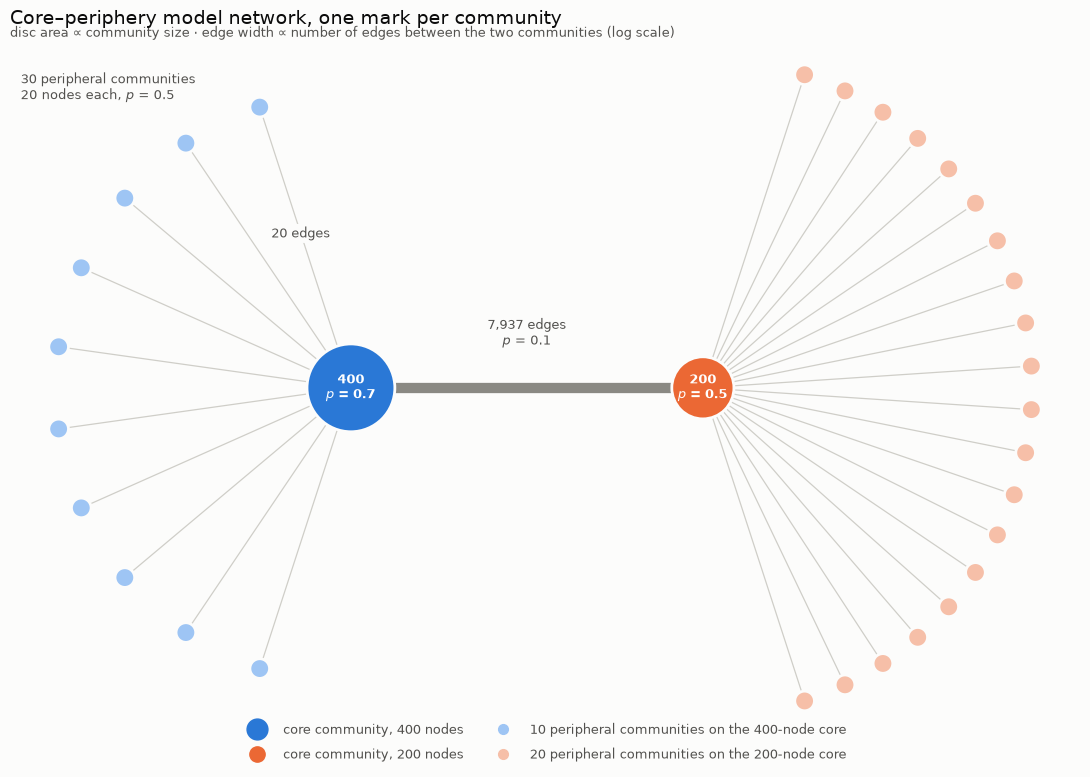

In [3]:
model.plot_communities()
plt.show()

## 4. The same thing as a block matrix

The coarse view read off the adjacency of the 32 blocks: a bright diagonal
(dense communities), one strong core–core cell, a thin arm of 20-edge cells
joining each peripheral block to its core, and nothing anywhere else.

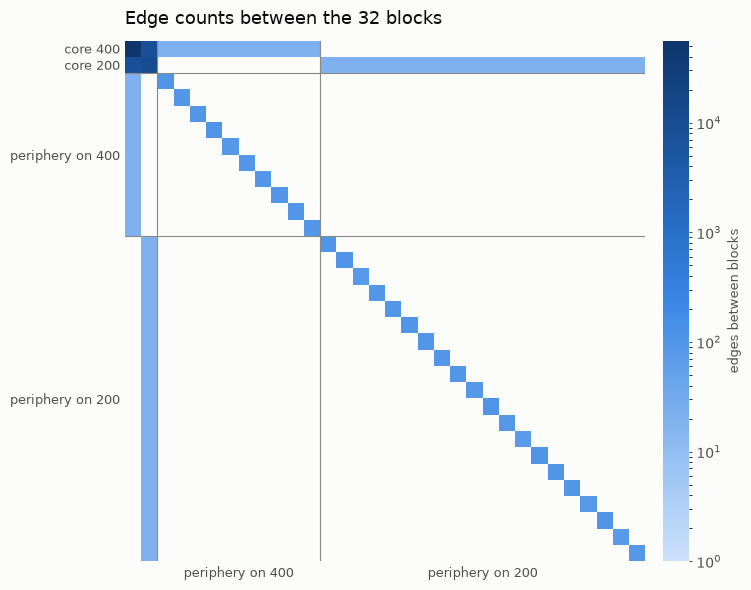

In [4]:
model.plot_block_matrix()
plt.show()